# ANN Lab 4 — Batch Gradient Descent & Stochastic Gradient Descent

| Field | Detail |
|---|---|
| **Name** | Muhammad Taqui |
| **Enrollment No** | 01-136221-021 |
| **Class** | BS AI (6-A) |

## Theory

### Batch Gradient Descent (BGD)
Computes gradients over the full training set each epoch:

$$\nabla_W J = -\frac{2}{m} \sum_{i=1}^{m} (y_i - f(W \cdot X_i + b)) \, X_i$$

$$W := W - \alpha \nabla_W J, \quad b := b - \alpha \nabla_b J$$

### Stochastic Gradient Descent (SGD)
Updates weights after **each** training sample — noisier but faster convergence on large datasets.

The sigmoid activation used here:

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \quad \sigma'(z) = \sigma(z)(1 - \sigma(z))$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Part 1 — Batch Gradient Descent

In [2]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x: np.ndarray) -> np.ndarray:
    s = sigmoid(x)
    return s * (1 - s)

def predict_bgd(X: np.ndarray, W: np.ndarray, b: float) -> np.ndarray:
    return np.array([sigmoid(np.dot(W, x) + b) for x in X])

def train_bgd(
    X: np.ndarray,
    y: np.ndarray,
    lr: float = 0.1,
    epochs: int = 60
):
    m, n = X.shape
    W = np.random.randn(n) * 0.1
    b = 0.0
    loss_history = []

    for epoch in range(1, epochs + 1):
        preds = predict_bgd(X, W, b)
        errors = y - preds
        loss = np.mean(errors ** 2)
        loss_history.append(loss)

        grad_W = -2 / m * np.dot(errors, X)
        grad_b = -2 / m * np.sum(errors)
        W -= lr * grad_W
        b -= lr * grad_b

        if epoch % 10 == 0:
            print(f"Epoch {epoch}/{epochs}  Loss: {loss:.4f}")

    return W, b, loss_history

# XOR-like dataset with bipolar encoding
X_train = np.array([[1,1,1,1], [-1,1,-1,-1], [1,1,-1,1], [1,-1,-1,1]], dtype=float)
y_train = np.array([1, 0, 0, 1], dtype=float)

np.random.seed(42)
W_final, b_final, bgd_losses = train_bgd(X_train, y_train, lr=0.1, epochs=60)

Epoch 10/60  Loss: 0.1194
Epoch 20/60  Loss: 0.0795
Epoch 30/60  Loss: 0.0579
Epoch 40/60  Loss: 0.0440
Epoch 50/60  Loss: 0.0346
Epoch 60/60  Loss: 0.0278


In [3]:
raw_preds = predict_bgd(X_train, W_final, b_final)
class_preds = (raw_preds >= 0.5).astype(int)

print("\nBGD Final predictions:")
for xi, pi in zip(X_train, class_preds):
    print(f"  Input {xi.astype(int).tolist()} -> {pi}")
print(f"\nFinal weights: {W_final.round(4)}")
print(f"Final bias:    {b_final:.4f}")


BGD Final predictions:
  Input [1, 1, 1, 1] -> 1
  Input [-1, 1, -1, -1] -> 0
  Input [1, 1, -1, 1] -> 0
  Input [1, -1, -1, 1] -> 1

Final weights: [ 0.721  -1.4037  1.4093  0.8236]
Final bias:    0.1251


## Part 2 — Stochastic Gradient Descent

In [4]:
def train_sgd(
    X: np.ndarray,
    y: np.ndarray,
    lr: float = 0.1,
    epochs: int = 25
):
    m, n = X.shape
    W = np.random.randn(n) * 0.1
    b = 0.0
    loss_history = []

    for epoch in range(1, epochs + 1):
        epoch_losses = []
        for i in range(m):
            pred = sigmoid(np.dot(W, X[i]) + b)
            error = y[i] - pred
            sample_loss = error ** 2
            epoch_losses.append(sample_loss)

            W += lr * error * X[i]
            b += lr * error

        epoch_loss = np.mean(epoch_losses)
        loss_history.append(epoch_loss)

        if epoch % 5 == 0:
            print(f"Epoch {epoch}/{epochs}  Avg Loss: {epoch_loss:.4f}")

    return W, b, loss_history

np.random.seed(42)
W_sgd, b_sgd, sgd_losses = train_sgd(X_train, y_train, lr=0.1, epochs=25)

Epoch 5/25  Avg Loss: 0.1320
Epoch 10/25  Avg Loss: 0.0864
Epoch 15/25  Avg Loss: 0.0619
Epoch 20/25  Avg Loss: 0.0464
Epoch 25/25  Avg Loss: 0.0360


In [5]:
raw_sgd = predict_bgd(X_train, W_sgd, b_sgd)
class_sgd = (raw_sgd >= 0.5).astype(int)

print("\nSGD Final predictions:")
for xi, pi in zip(X_train, class_sgd):
    print(f"  Input {xi.astype(int).tolist()} -> {pi}")
print(f"\nFinal weights: {W_sgd.round(4)}")
print(f"Final bias:    {b_sgd:.4f}")


SGD Final predictions:
  Input [1, 1, 1, 1] -> 1
  Input [-1, 1, -1, -1] -> 0
  Input [1, 1, -1, 1] -> 0
  Input [1, -1, -1, 1] -> 1

Final weights: [ 0.6776 -1.3135  1.2862  0.7803]
Final bias:    0.1045


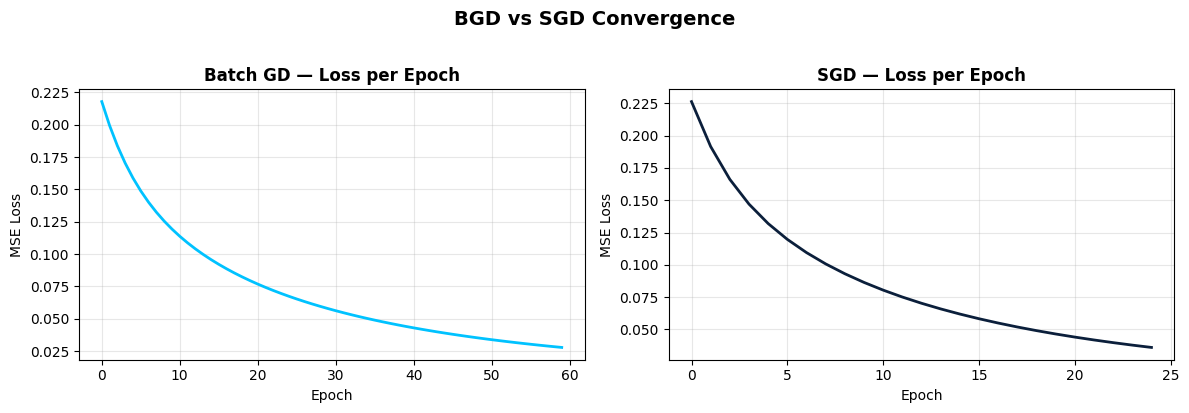

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(bgd_losses, color='#00C2FF', linewidth=2)
axes[0].set_title('Batch GD — Loss per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(sgd_losses, color='#0B1F3B', linewidth=2)
axes[1].set_title('SGD — Loss per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].grid(True, alpha=0.3)

plt.suptitle('BGD vs SGD Convergence', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Conclusion

BGD produces smooth loss curves; SGD is noisier per epoch but can converge faster when data is large. Both reach comparable solutions on this small dataset. SGD's per-sample updates make it preferable at scale.

In [7]:
# iTaqiZ - PK